# Fraud & Anomaly Detection Engine

## Executive Summary

This project develops a deployable Fraud & Anomaly Detection Engine for financial transactions. The system addresses a critical business challenge: detecting fraudulent activity in highly imbalanced data while minimizing operational disruptions caused by false alarms.

A supervised machine learning model is used to estimate fraud probability based on known patterns, while an unsupervised anomaly detection model identifies unusual transactions that may represent previously unseen fraud behaviors.

The final system provides:

- Fraud probability for each transaction  
- Anomaly score capturing deviation from normal behavior  
- Risk classification to support decision-making  
- Actionable flag indicating whether intervention is required  

By combining predictive modeling with anomaly detection, the system balances detection effectiveness with operational efficiency, enabling real-time risk assessment and proactive fraud prevention.

---

## 1. Business Problem

Financial institutions must detect fraudulent transactions quickly to prevent monetary loss, reputational damage, and regulatory consequences. Fraud is a rare event, making it difficult to identify using traditional methods.

Key challenges include:

- Extremely imbalanced data (fraud is rare)
- High cost of missed fraud (false negatives)
- Operational cost of false alarms (false positives)
- Need to detect both known and novel fraud patterns

The objective is to build a system that identifies high-risk transactions early while maintaining manageable alert volume.

---

## 2. ML Formulation

### A) Fraud Detection → Binary Classification

Predict whether a transaction is fraudulent (1) or legitimate (0).

### B) Unknown Pattern Detection → Anomaly Detection

Identify transactions that deviate significantly from normal behavior, even if they do not match known fraud patterns.

---

## Methodology Overview

The project follows a structured machine learning workflow aligned with real-world production practices:

### 1. Data Understanding & Exploration
Analyze class imbalance, transaction patterns, feature distributions, and temporal behavior.

### 2. Data Preparation
Handle scaling, feature transformations, and stratified data splitting while preventing leakage.

### 3. Supervised Model Development
Train classification models to estimate fraud probability.

### 4. Imbalance Handling
Apply techniques such as class weighting and resampling to improve detection of rare fraud cases.

### 5. Threshold Optimization
Adjust decision thresholds to prioritize recall and minimize costly missed fraud.

### 6. Anomaly Detection
Use unsupervised methods to capture unusual transactions that may indicate emerging fraud strategies.

### 7. Hybrid Risk Scoring
Combine fraud probability and anomaly score into a unified risk measure.

---

## 3. Target Variable

Fraud Indicator (1 = Fraud, 0 = Legitimate)

---

## 4. Success Metrics

Fraud detection is a high-stakes problem where missing fraud is significantly more costly than raising false alarms.

### Primary Business Metric
Maximize Recall for Fraud (Class 1) to detect as many fraudulent transactions as possible.

### Model Quality Metric
Use PR-AUC and ROC-AUC to evaluate ranking performance independent of threshold.

### Balanced Metric
Monitor F1 Score to ensure precision remains operationally acceptable.

### Operational Strategy
Tune classification threshold based on business tolerance for false positives versus missed fraud.

---

## 5. Final Output

For each transaction, the system outputs:

- Fraud probability  
- Anomaly score  
- Combined risk score  
- Risk category (Low / Medium / High)  
- Decision flag for intervention  

---

## Project Goal

To develop a production-ready fraud detection system that integrates statistical learning with anomaly detection to support real-time risk management and decision-making.

---

# About Dataset
## Context
It is important that credit card companies are able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase.

## Content
The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.

---

# Importing Libraries

In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, precision_recall_fscore_support
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

---

# 1. Data Acquisition

In [2]:
df = pd.read_csv('./data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

We see that all our features have the correct data types, and we have no null values

In [6]:
class_counts = df['Class'].value_counts()
class_counts

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
total = class_counts[0] + class_counts[1]
fraud_percent = class_counts[1]/total
print(f"Percentage of Fraud records: {np.round(fraud_percent,5) * 100}")

Percentage of Fraud records: 0.173


We see that this dataset is heavily imbalanced, as we have ~99.827% legitimate transactions, while only ~0.173% fraudulent transactions. 

So in this case, relying on accuracy will be useless as if we blindly predicted all transactions to be legitimate, we will end up with ~99.998% accuracy, and will not find any fraudulent transactions, which is the sole purpose of this project

---

# 2. EDA

Let us first observe the amount distribution

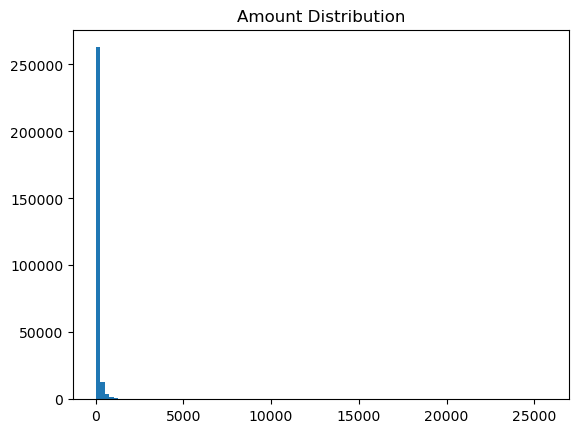

In [8]:
plt.hist(df['Amount'], bins=100)
plt.title('Amount Distribution')
plt.show()

The transaction amount distribution is highly right-skewed: most transactions are small, while a small number of transactions are very large. This suggests that raw amount may require transformation or careful interpretation in later stages.

Let us now look at the mean amount of a legitimate transaction compared to a fraudulent transaction

In [9]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

print(f"Fraud Mean Amount: {fraud['Amount'].mean()}")
print(f"Legitimate Mean Amount: {legit['Amount'].mean()}")

Fraud Mean Amount: 122.21132113821139
Legitimate Mean Amount: 88.29102242231328


We observe that the mean amount of fradulent transactions is higher than the mean amount of legitimate transactions. The reason could be that this is a skewed distribution, in which outliers dominate the mean. So just looking at this can be misleading

Since we have all our features as floats, let us plot them against the target feature thorugh box plots

In [10]:
columns = df.columns.tolist()
columns.remove('Time')
columns.remove('Class')
target = 'Class'

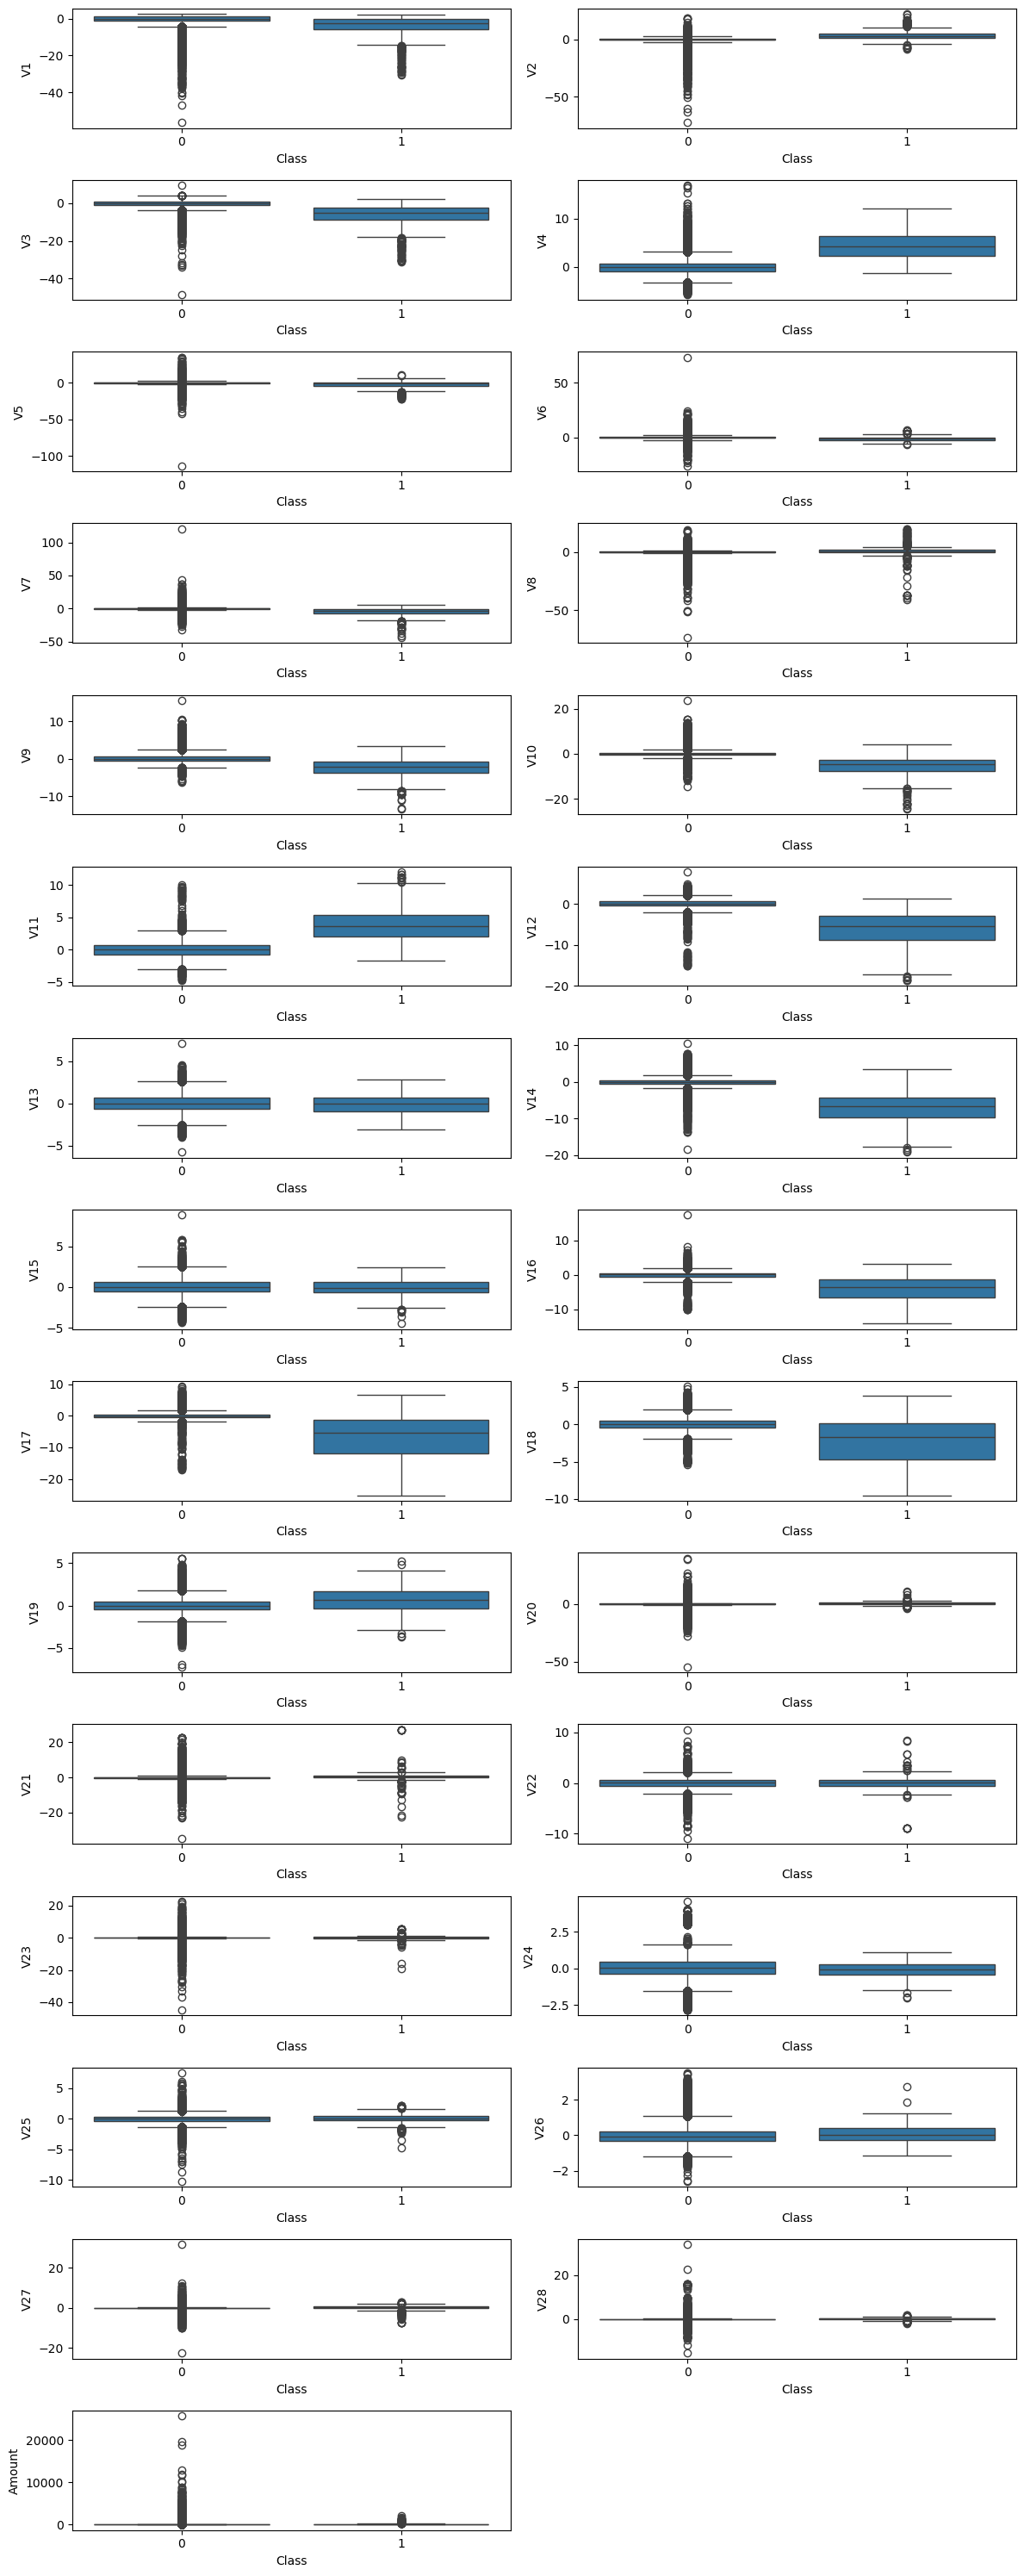

In [11]:
n_cols = 2
n_rows = (len(columns) + 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 2))

for i, col in enumerate(columns):
    sns.boxplot(data=df, x='Class', y=col, ax=axes.flatten()[i])

if len(columns) % n_cols != 0:
    fig.delaxes(axes.flatten()[-1])

plt.tight_layout()
plt.show()


Several PCA components exhibit noticeable distribution differences between fraud and legitimate transactions, suggesting that discriminatory signal exists in the feature space. However, the overlap between classes remains substantial, so useful predictive power will likely arise from the combination of multiple features rather than any single feature in isolation.

Let us explore the amount feature further, as it has a skewed distribution

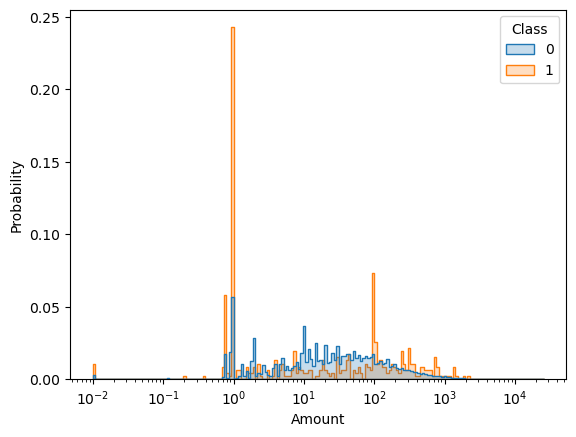

In [12]:
sns.histplot(data=df, x='Amount', hue='Class', 
             stat="probability", common_norm=False, 
             log_scale=True, element="step")
plt.show()

Fraud transactions in this dataset are concentrated in lower-value ranges, with a secondary cluster around moderate amounts. This suggests attackers may favor transactions that are less likely to trigger scrutiny while still yielding meaningful gain. However, legitimate transactions also occur in these ranges, indicating that amount alone is insufficient for reliable detection.

Now let us observe the occurence of frauds over time

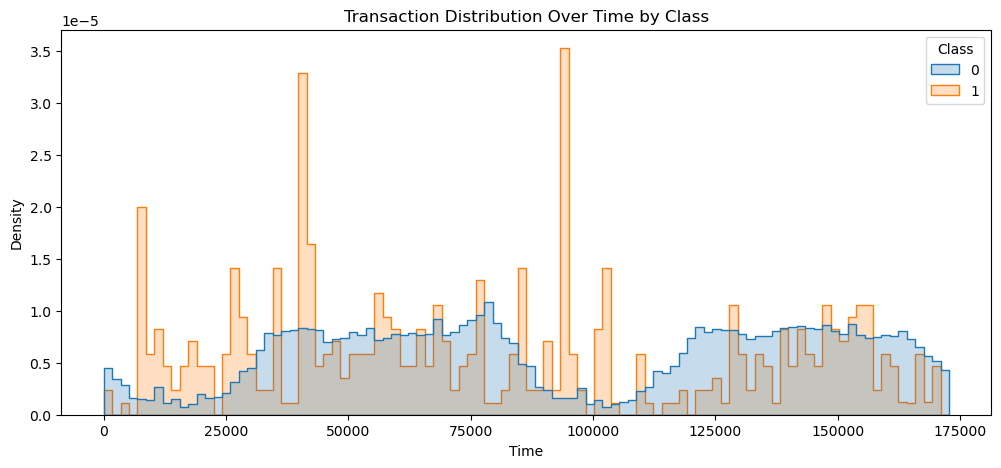

In [13]:
plt.figure(figsize=(12,5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Distribution Over Time by Class")
plt.show()

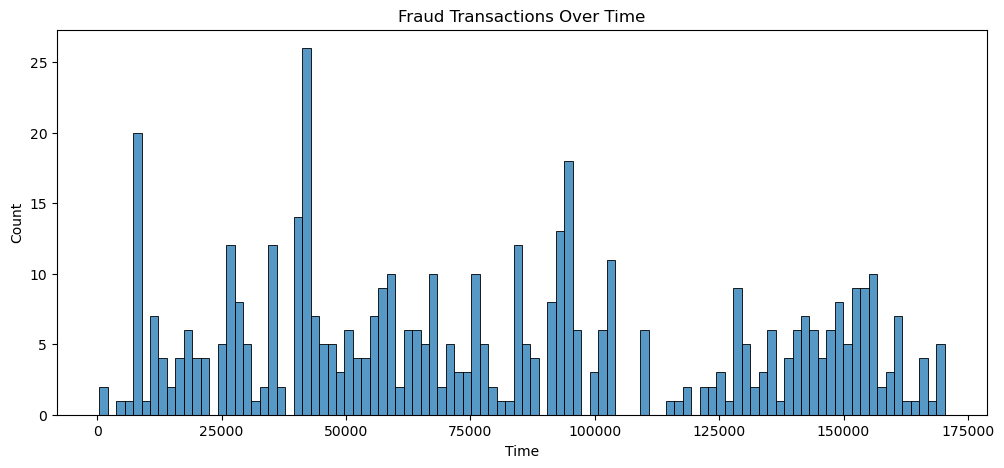

In [14]:
fraud = df[df["Class"] == 1]

plt.figure(figsize=(12,5))

sns.histplot(
    fraud["Time"],
    bins=100
)

plt.title("Fraud Transactions Over Time")
plt.show()

C:\Users\alina\AppData\Local\Temp\ipykernel_33016\163785787.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate_time = df.groupby("Time_bin")["Class"].mean()


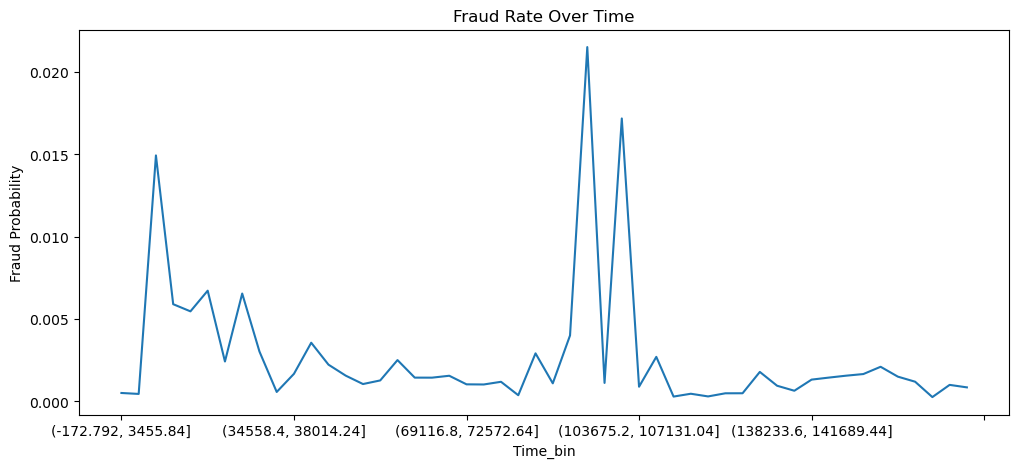

In [15]:
df["Time_bin"] = pd.cut(df["Time"], bins=50)
fraud_rate_time = df.groupby("Time_bin")["Class"].mean()
fraud_rate_time.plot(figsize=(12,5))
plt.title("Fraud Rate Over Time")
plt.ylabel("Fraud Probability")
plt.show()

Fraud transactions are present throughout the observation period but are not uniformly distributed. Instead, they appear in short bursts where the fraud rate temporarily increases. This suggests that fraudulent activity may occur in concentrated campaigns rather than continuously over time.

\
Let us now look at the correlation matrix for the features

In [16]:
corr_df = df.select_dtypes(['number']).corr()
corr_df = corr_df.loc[:, ['Time', 'Amount', 'Class']]
corr_df = corr_df.sort_values(by='Class', ascending=False)
# corr_df

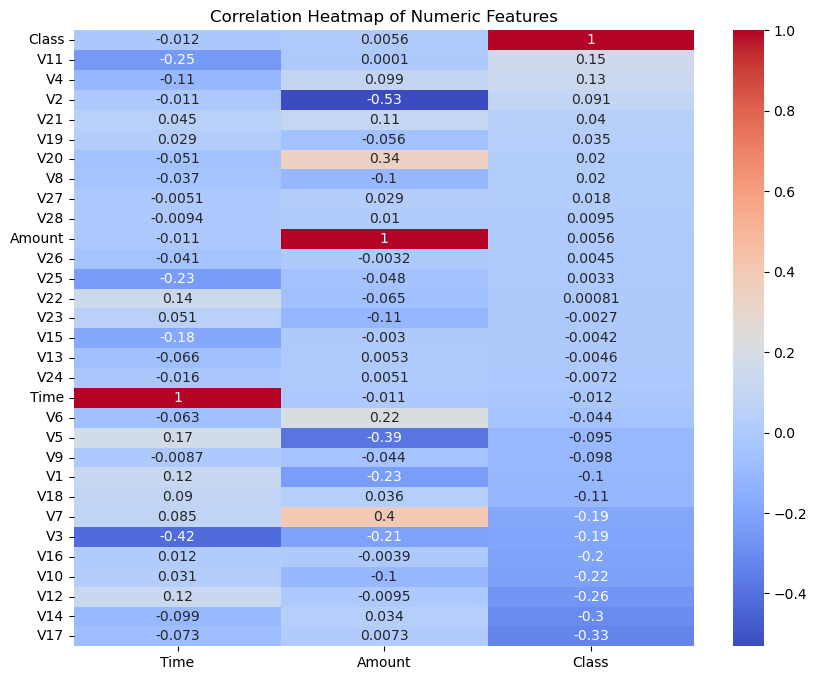

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, 
            annot=True,     # Add the correlation values as annotations
            cmap='coolwarm',# Choose a color map (e.g., 'coolwarm', 'RdBu', 'plasma')
           )
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

We skipped features V1-V28 in the heatmap, as they are PCA components, and orthogonal, meaning they are uncorrelated so there is no need for us to plot them here.

The correlation analysis shows that no single feature has a strong linear relationship with the fraud label. This suggests that fraudulent behavior is not driven by any individual variable but rather by complex, possibly nonlinear interactions among multiple features.

---

# 3. Data Preparation

First let us separate our target feature from our features

In [18]:
# Dropping Time_bin as it was only created for EDA
df = df.drop('Time_bin', axis=1) 

X = df.drop(['Class'], axis=1)
y = df['Class']

Now let us split train and test data

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y, test_size=0.2)

In [20]:
numeric_features = X.select_dtypes(['number']).columns.tolist()
categorical_features = X.select_dtypes(['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
    ]
)

---

# 4. Model Building

## 4.1 Baseline Model

Let us now create a base Logistic Regression Pipeline

In [21]:
base_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression())
    ]
)
base_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount'])])),
                ('model', LogisticRegression())])

In [22]:
y_train_pred = base_pipe.predict(X_train)
y_train_prob = base_pipe.predict_proba(X_train)[:, 1]

print(f'ROC AUC Score: {roc_auc_score(y_train, y_train_prob)}')
print(classification_report(y_train, y_train_pred))

ROC AUC Score: 0.9829790415951027
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       0.88      0.63      0.73       394

    accuracy                           1.00    227845
   macro avg       0.94      0.81      0.87    227845
weighted avg       1.00      1.00      1.00    227845



In [23]:
y_test_pred = base_pipe.predict(X_test)
y_test_prob = base_pipe.predict_proba(X_test)[:, 1]

print(f'ROC AUC Score: {roc_auc_score(y_test, y_test_prob)}')
print(classification_report(y_test, y_test_pred))

ROC AUC Score: 0.9605494455801453
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [24]:
def plot_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
    disp.plot(cmap=plt.cm.Blues)
    plt.show()

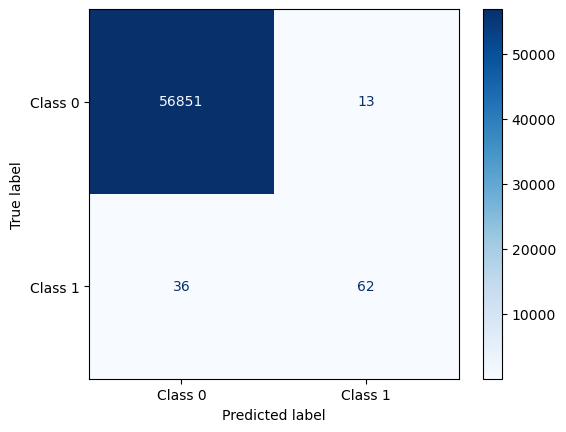

In [25]:
plot_confusion_matrix(y_test, y_test_pred)

Our base model shows strong capability of distinguishing between classes. We see that the ROC AUC scores of train and test data are very close, meaning that our model generalizes well on unseen data. Furthermore, we see that this base model is able to catch 63% of the fraudulent transactions, which for a base model without weight balancing or threshold tuning, is good as is

In [26]:
def plot_pr_curve(y_test, y_prob, label):
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=label)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

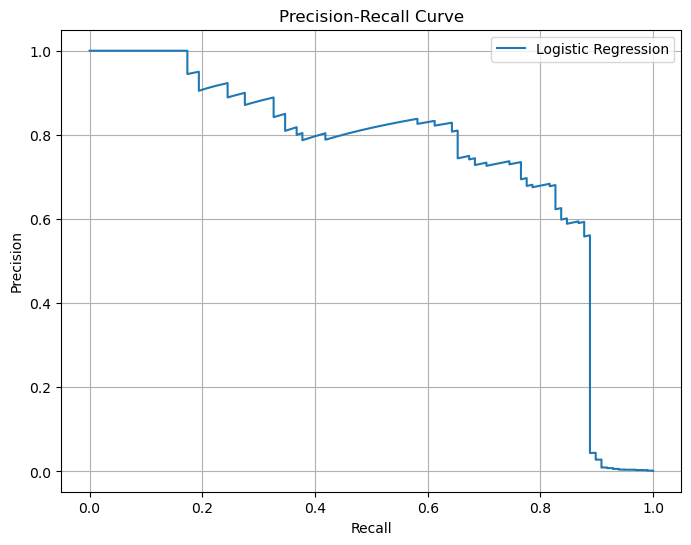

In [27]:
plot_pr_curve(y_test, y_test_prob, label='Logistic Regression')

The Precision–Recall curve shows that the model maintains high precision across a wide range of recall values, indicating strong discrimination ability for the minority fraud class. As recall increases, precision declines, reflecting the expected tradeoff between detecting more fraud cases and generating more false positives.

\
Let us now apply threshold tuning to maximize recall while maintaining a respectable precision

In [28]:
def tune_thresholds(y_test, y_test_prob):
    thresholds = np.arange(0.05, 1, 0.05)

    for t in thresholds:
        y_pred = (y_test_prob >= t).astype(int)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average='binary'
        )
        print(f"Threshold={t:.2f} | Precision={prec:.3f} | Recall={rec:.3f} | F1={f1:.3f}")

In [29]:
tune_thresholds(y_test, y_test_prob)

Threshold=0.05 | Precision=0.653 | Recall=0.827 | F1=0.730
Threshold=0.10 | Precision=0.701 | Recall=0.765 | F1=0.732
Threshold=0.15 | Precision=0.728 | Recall=0.765 | F1=0.746
Threshold=0.20 | Precision=0.735 | Recall=0.735 | F1=0.735
Threshold=0.25 | Precision=0.729 | Recall=0.714 | F1=0.722
Threshold=0.30 | Precision=0.731 | Recall=0.694 | F1=0.712
Threshold=0.35 | Precision=0.742 | Recall=0.673 | F1=0.706
Threshold=0.40 | Precision=0.753 | Recall=0.653 | F1=0.699
Threshold=0.45 | Precision=0.808 | Recall=0.643 | F1=0.716
Threshold=0.50 | Precision=0.827 | Recall=0.633 | F1=0.717
Threshold=0.55 | Precision=0.827 | Recall=0.633 | F1=0.717
Threshold=0.60 | Precision=0.827 | Recall=0.633 | F1=0.717
Threshold=0.65 | Precision=0.824 | Recall=0.622 | F1=0.709
Threshold=0.70 | Precision=0.831 | Recall=0.602 | F1=0.698
Threshold=0.75 | Precision=0.836 | Recall=0.571 | F1=0.679
Threshold=0.80 | Precision=0.828 | Recall=0.541 | F1=0.654
Threshold=0.85 | Precision=0.823 | Recall=0.520 | F1=0.6

Since the dataset is highly imbalanced, accuracy is not an appropriate metric for decision making. In fraud detection, missing fraudulent transactions (false negatives) is costly, but excessive false positives can also disrupt legitimate customers. Therefore, we select a decision threshold that maximizes recall while maintaining an acceptable level of precision (≥ 0.60).

From the threshold analysis, a cutoff of 0.05 achieves the highest recall (0.827) while keeping precision at a reasonable level (0.653). This threshold provides a balanced trade-off between detecting fraudulent transactions and limiting false alarms, and is therefore chosen as the operating point for the baseline model.

In [30]:
y_test_pred = (y_test_prob >= 0.05).astype(int)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.65      0.83      0.73        98

    accuracy                           1.00     56962
   macro avg       0.83      0.91      0.86     56962
weighted avg       1.00      1.00      1.00     56962



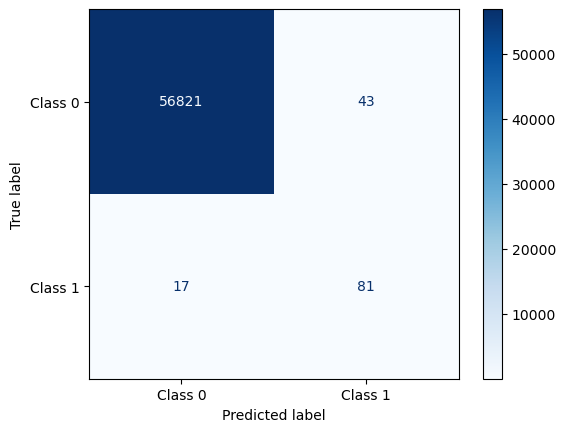

In [31]:
plot_confusion_matrix(y_test, y_test_pred)

We see our False Negatives decreased from 36 previously, to 17 now, at the cost of True positives decreasing from 13 previously, to now 43. This is expected behavior as we can only prioritize Precision or Recall, and we chose to maximize Recall

## 4.2 Using balanced class weights

Now we will use balanced class weight on the Logistic Regression model, to see how that affects the model's performance

In [32]:
balanced_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(class_weight='balanced'))
    ]
)

balanced_pipe.fit(X_train, y_train)

y_balanced_train_pred = balanced_pipe.predict(X_train)
y_balanced_train_prob = balanced_pipe.predict_proba(X_train)[:,1]

print(f'ROC AUC Score: {roc_auc_score(y_train, y_balanced_train_prob)}')
print(classification_report(y_train, y_balanced_train_pred))

ROC AUC Score: 0.9894389257310221
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    227451
           1       0.06      0.92      0.12       394

    accuracy                           0.98    227845
   macro avg       0.53      0.95      0.55    227845
weighted avg       1.00      0.98      0.99    227845



In [33]:
y_balanced_test_pred = balanced_pipe.predict(X_test)
y_balanced_test_prob = balanced_pipe.predict_proba(X_test)[:, 1]

print(f'ROC AUC Score: {roc_auc_score(y_test, y_balanced_test_prob)}')
print(classification_report(y_test, y_balanced_test_pred))

ROC AUC Score: 0.9720834996210077
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



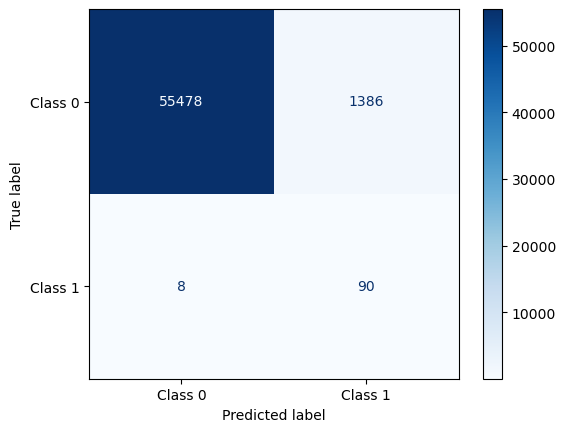

In [34]:
plot_confusion_matrix(y_test, y_balanced_test_pred)

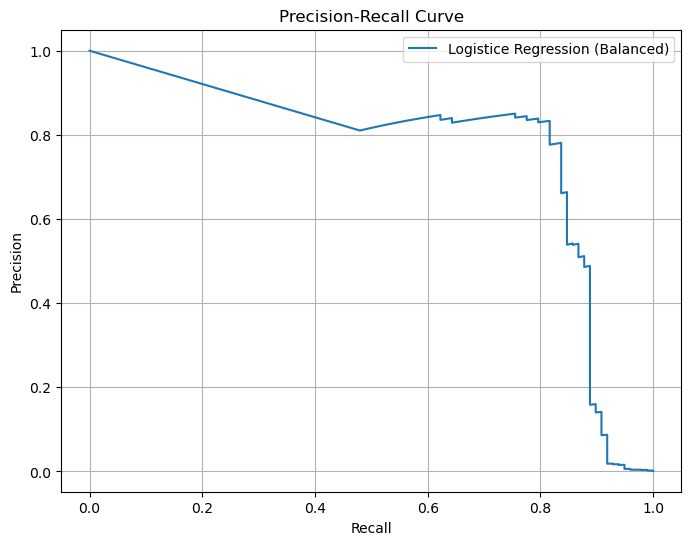

In [35]:
plot_pr_curve(y_test, y_balanced_test_prob, label='Logistice Regression (Balanced)')

After applying balanced class weights, recall for the minority class increased from 0.83 to 0.92. However, precision dropped sharply from 0.65 to 0.06.

This occurs because balanced class weighting penalizes misclassification of minority samples much more heavily than majority samples. In particular, false negatives (missed fraud cases) become very costly during training.

As a result, the model shifts its decision boundary to avoid missing fraud cases, predicting the minority class far more often. While this reduces false negatives and increases recall, it dramatically increases false positives, causing precision to collapse.

\
Let us now apply threshold tuning to this model

In [36]:
tune_thresholds(y_test, y_balanced_test_prob)

Threshold=0.05 | Precision=0.005 | Recall=0.959 | F1=0.010
Threshold=0.10 | Precision=0.008 | Recall=0.949 | F1=0.016
Threshold=0.15 | Precision=0.012 | Recall=0.949 | F1=0.024
Threshold=0.20 | Precision=0.016 | Recall=0.939 | F1=0.032
Threshold=0.25 | Precision=0.021 | Recall=0.918 | F1=0.042
Threshold=0.30 | Precision=0.027 | Recall=0.918 | F1=0.053
Threshold=0.35 | Precision=0.034 | Recall=0.918 | F1=0.066
Threshold=0.40 | Precision=0.042 | Recall=0.918 | F1=0.081
Threshold=0.45 | Precision=0.051 | Recall=0.918 | F1=0.096
Threshold=0.50 | Precision=0.061 | Recall=0.918 | F1=0.114
Threshold=0.55 | Precision=0.073 | Recall=0.918 | F1=0.135
Threshold=0.60 | Precision=0.087 | Recall=0.908 | F1=0.158
Threshold=0.65 | Precision=0.102 | Recall=0.908 | F1=0.183
Threshold=0.70 | Precision=0.121 | Recall=0.908 | F1=0.214
Threshold=0.75 | Precision=0.140 | Recall=0.898 | F1=0.243
Threshold=0.80 | Precision=0.160 | Recall=0.888 | F1=0.271
Threshold=0.85 | Precision=0.185 | Recall=0.888 | F1=0.3

Threshold tuning on the weighted logistic regression model did not recover precision to an acceptable level. Although recall remained very high across thresholds, precision improved only marginally and stayed substantially below the baseline model. This indicates that class weighting made the model overly aggressive toward the minority class, producing too many false positives. Therefore, for this dataset and model, balanced class weighting does not provide a practical improvement over the baseline approach.

## 4.3 Applying Synthetic Minority Oversampling (SMOTE)

Since class weighting did not produce a desirable balance between precision and recall, we next apply Synthetic Minority Oversampling Technique (SMOTE). This method generates synthetic samples for the minority class (fraudulent transactions) to reduce class imbalance in the training data. By increasing the representation of fraud cases, the model is expected to learn minority-class patterns more effectively without simply duplicating existing samples.

In [37]:
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

y_train_sm.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

SMOTE made it so that now we have the same number of fradulent transaction records (synthetic + real). Now we will fit the baseline model with the new training data, to see if this improved our models performance or not

In [38]:
base_pipe.fit(X_train_sm, y_train_sm)

y_sm_train_pred = base_pipe.predict(X_train_sm)
y_sm_train_prob = base_pipe.predict_proba(X_train_sm)[:,1]

print(f"ROC AUC Score: {roc_auc_score(y_train_sm, y_sm_train_prob)}")
print(classification_report(y_train_sm, y_sm_train_pred))

ROC AUC Score: 0.9977629350466476
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    227451
           1       0.99      0.97      0.98    227451

    accuracy                           0.98    454902
   macro avg       0.98      0.98      0.98    454902
weighted avg       0.98      0.98      0.98    454902



In [39]:
y_sm_test_pred = base_pipe.predict(X_test)
y_sm_test_prob = base_pipe.predict_proba(X_test)[:, 1]

print(f"ROC AUC Score: {roc_auc_score(y_test, y_sm_test_prob)}")
print(classification_report(y_test, y_sm_test_pred))

ROC AUC Score: 0.9764816590676788
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



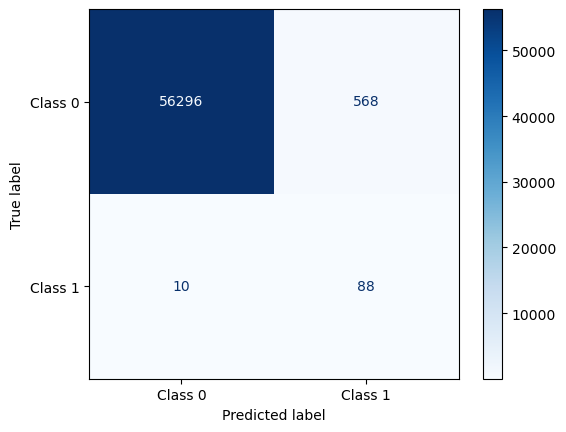

In [40]:
plot_confusion_matrix(y_test, y_sm_test_pred)

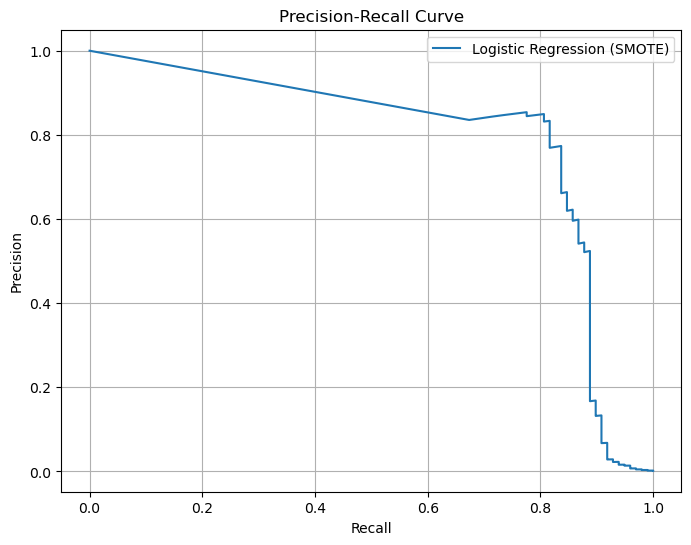

In [41]:
plot_pr_curve(y_test, y_sm_test_prob, label='Logistic Regression (SMOTE)')

After applying SMOTE, the model achieves a substantially higher recall of 0.90, compared to the baseline recall of 0.63. However, this improvement comes at a significant cost: precision drops sharply from 0.83 to 0.13.

This indicates that although the model now detects most fraudulent transactions, it also incorrectly flags a large number of legitimate transactions as fraud, resulting in many false positives.

SMOTE balances the training data by generating synthetic minority-class samples, enabling the model to learn fraud patterns more effectively. However, this also alters the class distribution seen during training. When evaluated on the original highly imbalanced test set, the model tends to over-predict fraud, since it was trained on data where fraud cases were artificially common.

As a result, recall improves substantially, but precision deteriorates sharply.

To obtain a more practical balance between detecting fraud and minimizing false alarms, we will perform threshold tuning to identify a decision threshold that maintains acceptable precision while maximizing recall.

In [42]:
tune_thresholds(y_test, y_sm_test_prob)

Threshold=0.05 | Precision=0.013 | Recall=0.959 | F1=0.025
Threshold=0.10 | Precision=0.023 | Recall=0.929 | F1=0.044
Threshold=0.15 | Precision=0.034 | Recall=0.918 | F1=0.065
Threshold=0.20 | Precision=0.046 | Recall=0.918 | F1=0.087
Threshold=0.25 | Precision=0.059 | Recall=0.918 | F1=0.112
Threshold=0.30 | Precision=0.072 | Recall=0.908 | F1=0.134
Threshold=0.35 | Precision=0.088 | Recall=0.908 | F1=0.160
Threshold=0.40 | Precision=0.103 | Recall=0.908 | F1=0.184
Threshold=0.45 | Precision=0.119 | Recall=0.908 | F1=0.210
Threshold=0.50 | Precision=0.134 | Recall=0.898 | F1=0.233
Threshold=0.55 | Precision=0.151 | Recall=0.898 | F1=0.259
Threshold=0.60 | Precision=0.167 | Recall=0.898 | F1=0.282
Threshold=0.65 | Precision=0.186 | Recall=0.888 | F1=0.307
Threshold=0.70 | Precision=0.205 | Recall=0.888 | F1=0.333
Threshold=0.75 | Precision=0.227 | Recall=0.888 | F1=0.362
Threshold=0.80 | Precision=0.260 | Recall=0.888 | F1=0.402
Threshold=0.85 | Precision=0.314 | Recall=0.888 | F1=0.4

Although SMOTE significantly improved recall, threshold tuning could not restore precision to a level comparable with the baseline model. Even at very high thresholds, the model continued to produce a large number of false positives. Therefore, SMOTE did not yield a practically superior model for this fraud detection task.

## 4.4 Trying Random Forest

Before moving forward, we will first try other models, namely Random Forest, and XGBoost. The reason for this experimentation is to find out whether an ensemble model can yield better results than our baseline model.

In [43]:
rdf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ]
)

rdf_pipeline.fit(X_train, y_train)
y_rdf_train_pred = rdf_pipeline.predict(X_train)
y_rdf_train_prob = rdf_pipeline.predict_proba(X_train)[:,1]

print(f"ROC AUC Score: {roc_auc_score(y_train, y_rdf_train_prob)}")
print(classification_report(y_train, y_rdf_train_pred))

ROC AUC Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845



In [44]:
y_rdf_test_pred = rdf_pipeline.predict(X_test)
y_rdf_test_prob = rdf_pipeline.predict_proba(X_test)[:,1]

print(f"ROC AUC Score: {roc_auc_score(y_test, y_rdf_test_prob)}")
print(classification_report(y_test, y_rdf_test_pred))

ROC AUC Score: 0.9630272515590367
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



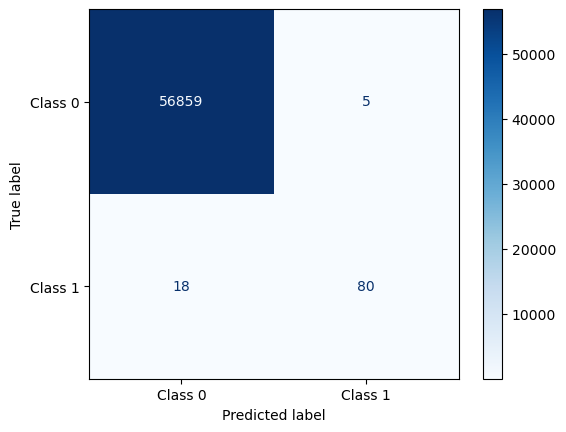

In [45]:
plot_confusion_matrix(y_test, y_rdf_test_pred)

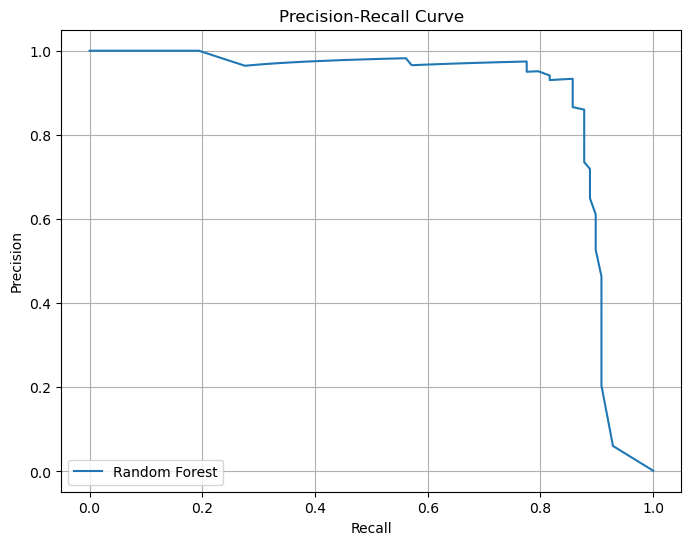

In [46]:
plot_pr_curve(y_test, y_rdf_test_prob, label="Random Forest")

In [47]:
tune_thresholds(y_test, y_rdf_test_prob)

Threshold=0.05 | Precision=0.527 | Recall=0.898 | F1=0.664
Threshold=0.10 | Precision=0.719 | Recall=0.888 | F1=0.795
Threshold=0.15 | Precision=0.789 | Recall=0.878 | F1=0.831
Threshold=0.20 | Precision=0.796 | Recall=0.878 | F1=0.835
Threshold=0.25 | Precision=0.819 | Recall=0.878 | F1=0.847
Threshold=0.30 | Precision=0.860 | Recall=0.878 | F1=0.869
Threshold=0.35 | Precision=0.894 | Recall=0.857 | F1=0.875
Threshold=0.40 | Precision=0.933 | Recall=0.857 | F1=0.894
Threshold=0.45 | Precision=0.931 | Recall=0.827 | F1=0.876
Threshold=0.50 | Precision=0.941 | Recall=0.816 | F1=0.874
Threshold=0.55 | Precision=0.951 | Recall=0.786 | F1=0.860
Threshold=0.60 | Precision=0.974 | Recall=0.776 | F1=0.864
Threshold=0.65 | Precision=0.973 | Recall=0.735 | F1=0.837
Threshold=0.70 | Precision=0.973 | Recall=0.724 | F1=0.830
Threshold=0.75 | Precision=0.971 | Recall=0.673 | F1=0.795
Threshold=0.80 | Precision=0.968 | Recall=0.622 | F1=0.758
Threshold=0.85 | Precision=0.982 | Recall=0.551 | F1=0.7

The Random Forest model significantly outperforms the baseline Logistic Regression model. It achieves both higher precision and higher recall, indicating a better ability to capture complex, non-linear fraud patterns. Although the model fits the training data perfectly, its strong performance on the test set suggests that this behavior is expected rather than problematic overfitting.

Additionally, threshold tuning provides flexible control over the precision-recall trade-off, allowing the system to be adjusted based on business requirements.

## 4.5 Trying XGBoost

In [50]:
xgb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(n_estimators=100, objective='binary:logistic'))
    ]
)

xgb_pipeline.fit(X_train, y_train)

y_xgb_train_pred = xgb_pipeline.predict(X_train)
y_xgb_train_prob = xgb_pipeline.predict_proba(X_train)[:,1]

print(f"ROC AUC Score: {roc_auc_score(y_train, y_xgb_train_prob)}")
print(classification_report(y_train, y_xgb_train_pred))

ROC AUC Score: 0.9999997433485255
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845



In [51]:
y_xgb_test_pred = xgb_pipeline.predict(X_test)
y_xgb_test_prob = xgb_pipeline.predict_proba(X_test)[:,1]

print(f"ROC AUC Score: {roc_auc_score(y_test, y_xgb_test_prob)}")
print(classification_report(y_test, y_xgb_test_pred))

ROC AUC Score: 0.9389517272862999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



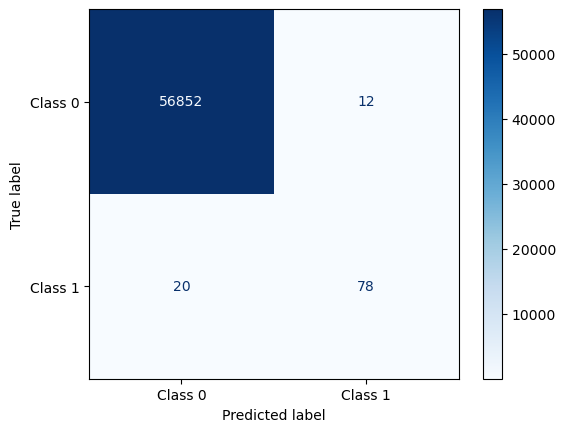

In [52]:
plot_confusion_matrix(y_test, y_xgb_test_pred)

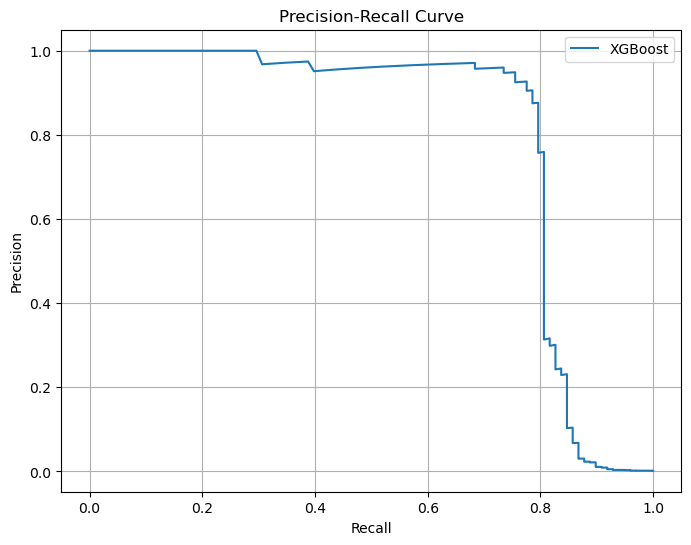

In [53]:
plot_pr_curve(y_test, y_xgb_test_prob, label="XGBoost")

In [54]:
tune_thresholds(y_test, y_xgb_test_prob)

Threshold=0.05 | Precision=0.752 | Recall=0.806 | F1=0.778
Threshold=0.10 | Precision=0.796 | Recall=0.796 | F1=0.796
Threshold=0.15 | Precision=0.804 | Recall=0.796 | F1=0.800
Threshold=0.20 | Precision=0.839 | Recall=0.796 | F1=0.817
Threshold=0.25 | Precision=0.848 | Recall=0.796 | F1=0.821
Threshold=0.30 | Precision=0.857 | Recall=0.796 | F1=0.825
Threshold=0.35 | Precision=0.857 | Recall=0.796 | F1=0.825
Threshold=0.40 | Precision=0.867 | Recall=0.796 | F1=0.830
Threshold=0.45 | Precision=0.867 | Recall=0.796 | F1=0.830
Threshold=0.50 | Precision=0.867 | Recall=0.796 | F1=0.830
Threshold=0.55 | Precision=0.867 | Recall=0.796 | F1=0.830
Threshold=0.60 | Precision=0.876 | Recall=0.796 | F1=0.834
Threshold=0.65 | Precision=0.885 | Recall=0.786 | F1=0.832
Threshold=0.70 | Precision=0.895 | Recall=0.786 | F1=0.837
Threshold=0.75 | Precision=0.895 | Recall=0.786 | F1=0.837
Threshold=0.80 | Precision=0.906 | Recall=0.786 | F1=0.842
Threshold=0.85 | Precision=0.916 | Recall=0.776 | F1=0.8

The Random Forest model outperforms both Logistic Regression and XGBoost in terms of precision and recall, providing the best overall balance for fraud detection. While XGBoost also improves upon the baseline model, it does not surpass Random Forest under default settings. This suggests that Random Forest is better suited for capturing the underlying patterns in this dataset at this stage.

Additionally, threshold tuning allows further control over the precision-recall trade-off, enabling the model to be adjusted based on business requirements.

## 4.6 Using GridSearchCV for Hyperparameter Tuning of RandomForest

Based on our results, we see that Random Forest provides the best results. So that will be our final model. We will now find the best hyperparameters for the model through GridSearch

In [55]:
# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# param_grid = {
#     'model__n_estimators': [100, 200],
#     'model__max_depth': [None, 10, 20],
#     'model__min_samples_split': [2, 5, 10],
#     'model__min_samples_leaf': [1, 2, 4],
#     'model__max_features': ['sqrt', 'log2']
# }

# grid = GridSearchCV(
#     estimator=rdf_pipeline,
#     param_grid=param_grid,
#     scoring='average_precision',
#     cv=cv,
#     n_jobs=-1,
#     verbose=2
# )

# grid.fit(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Time',
                                                                          'V1',
                                                                          'V2',
                                                                          'V3',
                                                                          'V4',
                                                                          'V5',
                                                                          'V6',
                                                                          'V7',
                                                                          'V8',
                                                                          'V9',
                                                                          'V10',
                                                                          'V11',
                                                                          'V12',
                                                                          'V13',
                                                                          'V14',
                                                                          'V15',
                                                                          'V16',
                                                                          'V17',
                                                                          'V18',
                                                                          'V19',
                                                                          'V20',
                                                                          'V21',
                                                                          'V22',
                                                                          'V23',
                                                                          'V24',
                                                                          'V25',
                                                                          'V26',
                                                                          'V27',
                                                                          'V28',
                                                                          'Amount'])])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200]},
             scoring='average_precision', verbose=2)

In [56]:
grid.best_params_

{'model__max_depth': 20,
 'model__max_features': 'log2',
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 2,
 'model__n_estimators': 100}

{'model__max_depth': 20,
 'model__max_features': 'log2',
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 2,
 'model__n_estimators': 100}

 Writing these down as GridSearch with Random Forest takes more than a couple of hours to complete, and I don't want to run it again

In [57]:
grid.best_score_

np.float64(0.8461515791659453)

In [58]:
best_rf = grid.best_estimator_

y_best_rf_pred = best_rf.predict(X_test)
y_best_rf_prob = best_rf.predict_proba(X_test)[:, 1]

print(f"ROC AUC Score: {roc_auc_score(y_test, y_best_rf_prob)}")
print(classification_report(y_test, y_best_rf_pred))

ROC AUC Score: 0.97681022676375
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



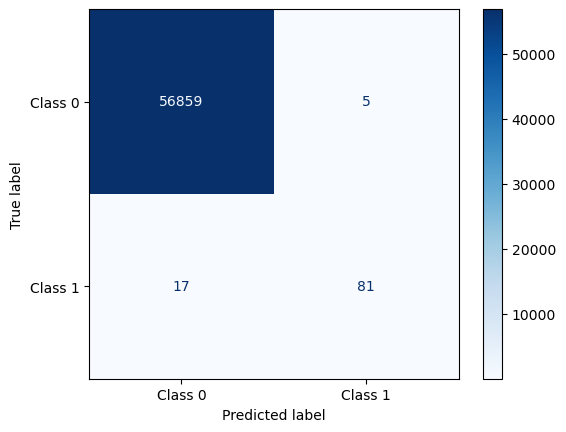

In [59]:
plot_confusion_matrix(y_test, y_best_rf_pred)

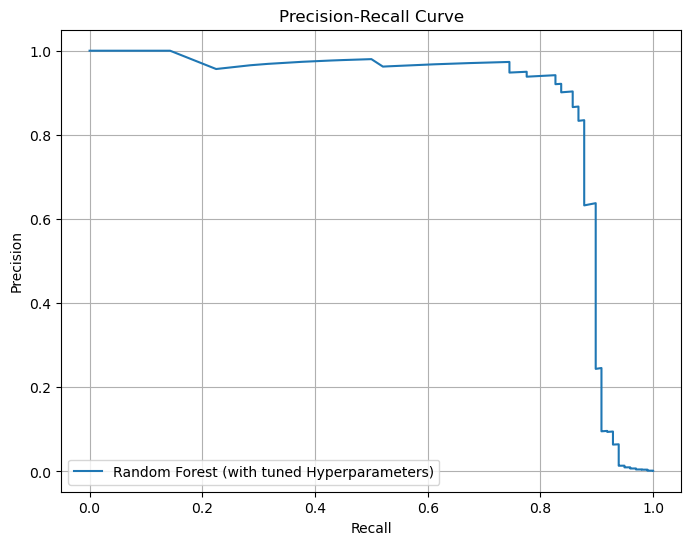

In [61]:
plot_pr_curve(y_test, y_best_rf_prob, label='Random Forest (with tuned Hyperparameters)')

In [62]:
tune_thresholds(y_test, y_best_rf_pred)

Threshold=0.05 | Precision=0.942 | Recall=0.827 | F1=0.880
Threshold=0.10 | Precision=0.942 | Recall=0.827 | F1=0.880
Threshold=0.15 | Precision=0.942 | Recall=0.827 | F1=0.880
Threshold=0.20 | Precision=0.942 | Recall=0.827 | F1=0.880
Threshold=0.25 | Precision=0.942 | Recall=0.827 | F1=0.880
Threshold=0.30 | Precision=0.942 | Recall=0.827 | F1=0.880
Threshold=0.35 | Precision=0.942 | Recall=0.827 | F1=0.880
Threshold=0.40 | Precision=0.942 | Recall=0.827 | F1=0.880
Threshold=0.45 | Precision=0.942 | Recall=0.827 | F1=0.880
Threshold=0.50 | Precision=0.942 | Recall=0.827 | F1=0.880
Threshold=0.55 | Precision=0.942 | Recall=0.827 | F1=0.880
Threshold=0.60 | Precision=0.942 | Recall=0.827 | F1=0.880
Threshold=0.65 | Precision=0.942 | Recall=0.827 | F1=0.880
Threshold=0.70 | Precision=0.942 | Recall=0.827 | F1=0.880
Threshold=0.75 | Precision=0.942 | Recall=0.827 | F1=0.880
Threshold=0.80 | Precision=0.942 | Recall=0.827 | F1=0.880
Threshold=0.85 | Precision=0.942 | Recall=0.827 | F1=0.8

---

# 5. Model Evaluation

## 5.1 Model Comparison

In [64]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'Tuned Random Forest',
        'Weighted Logistic',
        'SMOTE Logistic'
    ],
    'Precision': [0.83, 0.94, 0.87, 0.94, 0.06, 0.53],
    'Recall': [0.63, 0.82, 0.80, 0.83, 0.92, 0.88]
})

comparison.style.highlight_max(axis=0)
comparison.set_index('Model', inplace=True)
comparison

,Precision,Recall
Model,,
Logistic Regression,0.83,0.63
Random Forest,0.94,0.82
XGBoost,0.87,0.80
Tuned Random Forest,0.94,0.83
Weighted Logistic,0.06,0.92
SMOTE Logistic,0.53,0.88


## 5.2 Performance Analysis

From the comparison above, the Tuned Random Forest model provides the best overall balance between precision and recall. While Logistic Regression offers reasonable precision, its recall is significantly lower, meaning many fraudulent transactions are missed.

Both class weighting and SMOTE significantly improve recall, but at the cost of a drastic drop in precision, resulting in a large number of false positives. This makes them unsuitable for deployment in a real-world fraud detection system.

XGBoost improves upon the baseline model and captures more fraud cases, but still does not outperform Random Forest. The Tuned Random Forest achieves the highest recall while maintaining very high precision, making it the most reliable model among all candidates.

## 5.3 Business Impact

On the test dataset, the Tuned Random Forest model successfully detects 81 out of 98 fraudulent transactions, while missing only 17. At the same time, it incorrectly flags only 5 legitimate transactions as fraud.

This indicates that the model is highly effective at identifying fraudulent behavior while minimizing disruption to legitimate users. In a real-world setting, this would translate to strong fraud prevention with minimal customer inconvenience.

## 5.4 Threshold Decision

The model demonstrates highly confident predictions, as varying the decision threshold does not significantly affect performance. Therefore, the default threshold of 0.5 is retained.

## 5.5 Feature Importance

In [66]:
importances = best_rf.named_steps['model'].feature_importances_
columns = X_train.columns

feat_imp = pd.DataFrame(
    {
        'Feature': columns,
        'Importance': importances
    }
).sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
17,V17,0.146007
14,V14,0.133047
12,V12,0.117037
16,V16,0.087461
11,V11,0.065927
10,V10,0.063156
9,V9,0.053105
18,V18,0.029927
4,V4,0.029475
7,V7,0.029145


Feature importance analysis reveals that a subset of variables (primarily among the transformed V-features) contribute most significantly to fraud detection. These features likely capture key transactional patterns that differentiate fraudulent and legitimate behavior.

## 5.6 Final Model Selection

Feature importance analysis reveals that a subset of variables (primarily among the transformed V-features) contribute most significantly to fraud detection. These features likely capture key transactional patterns that differentiate fraudulent and legitimate behavior.

---

# 6. Anomaly Detection

## Using Isolation Forest

While supervised models such as Random Forest are effective at detecting known fraud patterns, they rely on historical labeled data and may fail to identify new or previously unseen types of fraud. In real-world systems, fraud patterns evolve over time, making it important to detect unusual or anomalous behavior beyond known labels.

To address this limitation, we introduce an unsupervised anomaly detection approach using Isolation Forest. Unlike classification models, Isolation Forest does not rely on labels and instead identifies transactions that are significantly different from the majority of the data. These anomalous transactions may correspond to potential fraud cases, including those not captured by the supervised model.

This step allows us to explore whether anomaly-based signals can complement supervised predictions and improve the overall fraud detection system.

In [68]:
iso = IsolationForest(n_estimators=100, contamination=0.001, random_state=42)

iso.fit(X_train)

IsolationForest(contamination=0.001, random_state=42)

Let us now extract the anomaly scores which quanitfy how anomalous a data point is

In [78]:
scores = iso.decision_function(X_test)

In [75]:
y_iso_pred = iso.predict(X_test)
y_iso_pred = (y_iso_pred == -1).astype(int)

In [76]:
print(classification_report(y_test, y_iso_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.39      0.26      0.31        98

    accuracy                           1.00     56962
   macro avg       0.69      0.63      0.65     56962
weighted avg       1.00      1.00      1.00     56962



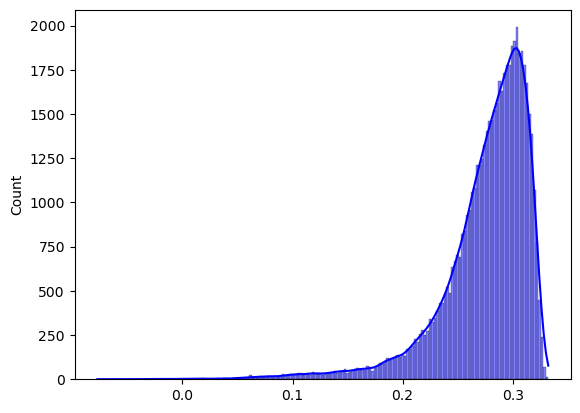

In [81]:
sns.histplot(scores[y_test == 0], label='Legit', color='blue', kde=True)
plt.show()

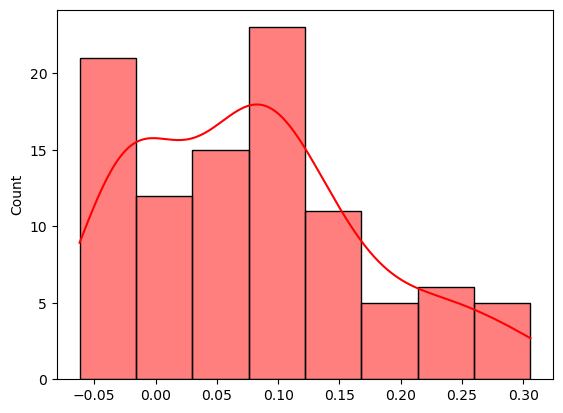

In [82]:
sns.histplot(scores[y_test == 1], label='Fraud', color='red', kde=True)
plt.show()

The anomaly score distributions show that fraudulent transactions tend to have lower anomaly scores compared to legitimate transactions, indicating that fraud is generally more anomalous in nature. However, there is significant overlap between the two distributions, suggesting that not all fraudulent transactions are strongly distinguishable as anomalies.

This explains the relatively low classification performance of Isolation Forest when used alone. While it is able to capture some fraudulent behavior, it is not sufficient as a standalone model. Instead, anomaly detection can serve as a complementary signal alongside supervised models.